### **Tugas 1** Text Classification 
Unduh dan unggah dataset: 
https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment, lalu jelaskan tujuan dataset ini

In [73]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/ganjar87/data_science_practice/main/Tweets.csv', delimiter=',')
df

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,569587686496825344,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,569587371693355008,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN
14637,569587242672398336,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN
14638,569587188687634433,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada)


In [74]:
df.shape

(14640, 15)

In [75]:
#Resize dataset
df_resize = df.iloc[:1000]
df_resize.shape

(1000, 15)

In [76]:
#Remove neutral
df_resize = df_resize[df_resize.airline_sentiment != 'neutral']
df_resize.shape

(728, 15)

In [77]:
df_resize

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
5,570300767074181121,negative,1.0000,Can't Tell,0.6842,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica seriously would pay $30 a fligh...,NaN,2015-02-24 11:14:33 -0800,NaN,Pacific Time (US & Canada)
6,570300616901320704,positive,0.6745,NaN,0.0000,Virgin America,NaN,cjmcginnis,NaN,0,"@VirginAmerica yes, nearly every time I fly VX...",NaN,2015-02-24 11:13:57 -0800,San Francisco CA,Pacific Time (US & Canada)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,569970938525016065,negative,1.0000,Late Flight,0.7065,United,NaN,tbird12lv,NaN,0,@united by the time I finally get to Dallas I ...,NaN,2015-02-23 13:23:55 -0800,Colorado,Mountain Time (US & Canada)
996,569970599377788928,negative,1.0000,Late Flight,1.0000,United,NaN,cristobalwong,NaN,0,@united I'm trying to get to my final destinat...,NaN,2015-02-23 13:22:35 -0800,San Francisco Bay Area,NaN
997,569970225443172353,negative,1.0000,Customer Service Issue,0.6667,United,NaN,itsmetsforme,NaN,0,@united that guy really has no customer servic...,NaN,2015-02-23 13:21:05 -0800,mets hell,NaN
998,569969999961391105,positive,0.6915,NaN,NaN,United,NaN,swampynomo,NaN,0,@united he has no priority and Iove it,NaN,2015-02-23 13:20:12 -0800,NJ/NYC,Eastern Time (US & Canada)


In [78]:
#Tokenization
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize
df_text = df_resize['text'].astype(str)
df_class = df_resize['airline_sentiment']
lines = df_text.values.tolist()
list_tokens = list()
for line in lines:
 line = line.replace("@VirginAmerica","")
 line = line.replace("@united","")
 tokens = word_tokenize(line)
 list_tokens.append(tokens)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [79]:
list_tokens

[['plus',
  'you',
  "'ve",
  'added',
  'commercials',
  'to',
  'the',
  'experience',
  '...',
  'tacky',
  '.'],
 ['it',
  "'s",
  'really',
  'aggressive',
  'to',
  'blast',
  'obnoxious',
  '``',
  'entertainment',
  "''",
  'in',
  'your',
  'guests',
  "'",
  'faces',
  '&',
  'amp',
  ';',
  'they',
  'have',
  'little',
  'recourse'],
 ['and', 'it', "'s", 'a', 'really', 'big', 'bad', 'thing', 'about', 'it'],
 ['seriously',
  'would',
  'pay',
  '$',
  '30',
  'a',
  'flight',
  'for',
  'seats',
  'that',
  'did',
  "n't",
  'have',
  'this',
  'playing',
  '.',
  'it',
  "'s",
  'really',
  'the',
  'only',
  'bad',
  'thing',
  'about',
  'flying',
  'VA'],
 ['yes',
  ',',
  'nearly',
  'every',
  'time',
  'I',
  'fly',
  'VX',
  'this',
  '“',
  'ear',
  'worm',
  '”',
  'won',
  '’',
  't',
  'go',
  'away',
  ':',
  ')'],
 ['@',
  'virginamerica',
  'Well',
  ',',
  'I',
  "didn't…but",
  'NOW',
  'I',
  'DO',
  '!',
  ':',
  '-D'],
 ['it',
  'was',
  'amazing',
  ',',

In [80]:
#Tokenization, removing stopwords and stemming
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
df_text = df_resize['text'].astype(str)
df_class = df_resize['airline_sentiment']
lines = df_text.values.tolist()
list_tokens_stem = list()
porter = PorterStemmer()
for line in lines:
 line = line.replace("@VirginAmerica","")
 line = line.replace("@united","")
 tokens = word_tokenize(line)
 # merubah tokens menjadi huruf kecil semua
 tokens = [w.lower() for w in tokens]
 tokens = [word for word in tokens if word.isalpha()]
 # menghapus stop words
 tokens = [word for word in tokens if not word in stopwords.words()]
 # melakukan stemming
 tokens = [porter.stem(word) for word in tokens]
 list_tokens_stem.append(tokens)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [81]:
print(lines[103])
print(list_tokens_stem[103])

@VirginAmerica having problems Flight Booking Problems on the web site. keeps giving me an error and to contact by phone.  phone is 30 minute wait.
['problem', 'flight', 'book', 'problem', 'web', 'site', 'give', 'error', 'contact', 'phone', 'phone', 'minut', 'wait']


In [82]:
#Removing stopword + lemmatization
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

df_text = df_resize['text'].astype(str)
df_class = df_resize['airline_sentiment']
lines = df_text.values.tolist()
list_tokens_lemma = list()
#porter = PorterStemmer()
lemmatizer = WordNetLemmatizer()
for line in lines:
 line = line.replace("@VirginAmerica","")
 line = line.replace("@united","")
 tokens = word_tokenize(line)
 # merubah tokens menjadi huruf kecil semua
 tokens = [w.lower() for w in tokens]
 tokens = [word for word in tokens if word.isalpha()]
 # menghapus stop words
 tokens = [word for word in tokens if not word in stopwords.words()]
 # melakukan lemmatization
 tokens = [lemmatizer.lemmatize(word) for word in tokens]
 list_tokens_lemma.append(tokens)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [83]:
list_tokens_lemma[103]

['problem',
 'flight',
 'booking',
 'problem',
 'web',
 'site',
 'giving',
 'error',
 'contact',
 'phone',
 'phone',
 'minute',
 'wait']

In [84]:
#Feature Extraction
#bag of words
from sklearn.feature_extraction.text import CountVectorizer
new_doc = list()
#ambil dari hasil lemmatization misalnya
for doc in list_tokens_lemma:
 row = ' '.join(doc)
 new_doc.append(row)
vectorizer = CountVectorizer(max_features=1000)
X_input_bow = vectorizer.fit_transform(new_doc)

In [85]:
list_tokens_lemma[:10]

[['added', 'commercial', 'experience', 'tacky'],
 ['aggressive',
  'blast',
  'obnoxious',
  'entertainment',
  'guest',
  'face',
  'amp',
  'recourse'],
 ['big'],
 ['pay', 'flight', 'seat', 'playing', 'flying'],
 ['time', 'fly', 'vx', 'ear', 'worm', 'away'],
 ['virginamerica'],
 ['amazing', 'arrived', 'hour', 'early'],
 ['lt', 'pretty', 'graphic', 'minimal', 'iconography'],
 ['great', 'deal', 'trip', 'australia', 'amp', 'trip', 'p'],
 ['virginmedia',
  'flying',
  'fabulous',
  'seductive',
  'sky',
  'stress',
  'away',
  'travel',
  'http']]

In [86]:
new_doc[:10]

['added commercial experience tacky',
 'aggressive blast obnoxious entertainment guest face amp recourse',
 'big',
 'pay flight seat playing flying',
 'time fly vx ear worm away',
 'virginamerica',
 'amazing arrived hour early',
 'lt pretty graphic minimal iconography',
 'great deal trip australia amp trip p',
 'virginmedia flying fabulous seductive sky stress away travel http']

In [87]:
print(vectorizer.get_feature_names_out())
print(X_input_bow.toarray())
print(vectorizer.vocabulary_)
print(X_input_bow.shape)

['absolute' 'access' 'account' 'add' 'added' 'adding' 'additional'
 'address' 'advance' 'afford' 'agent' 'ago' 'ahead' 'air' 'aircraft'
 'airline' 'airport' 'amazing' 'america' 'americanair' 'amp' 'angry'
 'answer' 'answering' 'anxiety' 'apology' 'app' 'apparently' 'applied'
 'appreciate' 'appropriate' 'arrived' 'arrives' 'arriving' 'asap' 'ase'
 'asked' 'assist' 'assistance' 'atrocious' 'attendant' 'austin' 'avail'
 'available' 'aviv' 'award' 'away' 'awesome' 'back' 'bag' 'baggage' 'bank'
 'bday' 'big' 'bin' 'birthday' 'bit' 'board' 'boarded' 'boarding' 'book'
 'booked' 'booking' 'bos' 'boston' 'bought' 'brand' 'break' 'broken'
 'browser' 'bug' 'business' 'button' 'buy' 'cabin' 'cake' 'call' 'called'
 'calling' 'cancelled' 'captain' 'car' 'card' 'carrier' 'carrieunderwood'
 'carry' 'carseat' 'case' 'caused' 'center' 'central' 'challenge' 'chance'
 'change' 'charge' 'charging' 'cheapflights' 'check' 'checked' 'checkin'
 'checking' 'cheese' 'child' 'city' 'claim' 'class' 'closed' 'cloth

In [88]:
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
new_doc = list()
#ambil dari hasil lemmatization misalnya
for doc in list_tokens_lemma:
    row = ' '.join(doc)
    new_doc.append(row)
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X_input_tfidf = tfidf_vectorizer.fit_transform(new_doc)
print(tfidf_vectorizer.get_feature_names_out())
print(X_input_tfidf.toarray())
print(tfidf_vectorizer.vocabulary_)
print(X_input_tfidf.shape)

['absolute' 'access' 'account' 'add' 'added' 'adding' 'additional'
 'address' 'advance' 'afford' 'agent' 'ago' 'ahead' 'air' 'aircraft'
 'airline' 'airport' 'amazing' 'america' 'americanair' 'amp' 'angry'
 'answer' 'answering' 'anxiety' 'apology' 'app' 'apparently' 'applied'
 'appreciate' 'appropriate' 'arrived' 'arrives' 'arriving' 'asap' 'ase'
 'asked' 'assist' 'assistance' 'atrocious' 'attendant' 'austin' 'avail'
 'available' 'aviv' 'award' 'away' 'awesome' 'back' 'bag' 'baggage' 'bank'
 'bday' 'big' 'bin' 'birthday' 'bit' 'board' 'boarded' 'boarding' 'book'
 'booked' 'booking' 'bos' 'boston' 'bought' 'brand' 'break' 'broken'
 'browser' 'bug' 'business' 'button' 'buy' 'cabin' 'cake' 'call' 'called'
 'calling' 'cancelled' 'captain' 'car' 'card' 'carrier' 'carrieunderwood'
 'carry' 'carseat' 'case' 'caused' 'center' 'central' 'challenge' 'chance'
 'change' 'charge' 'charging' 'cheapflights' 'check' 'checked' 'checkin'
 'checking' 'cheese' 'child' 'city' 'claim' 'class' 'closed' 'cloth

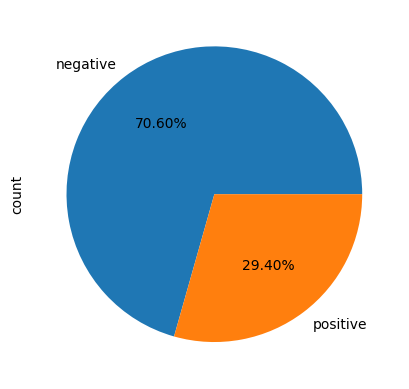

In [89]:
#Classification model
import matplotlib.pyplot as plt
data = df_resize['airline_sentiment'].value_counts()
data.plot(kind='pie',autopct='%.2f%%')
plt.show()

Accuracy  0.8264840182648402
Precision  0.7974842767295598
Recall  0.7810457516339869
Confusion matrix  [[137  16]
 [ 22  44]]
F1  0.7883089133089133


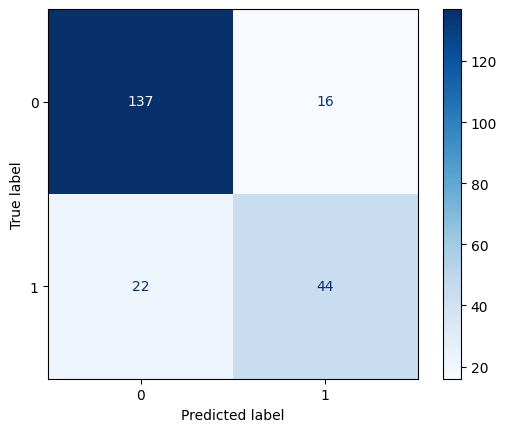

In [90]:
#MLP + BOW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from imblearn.metrics import sensitivity_specificity_support
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
import numpy as np
# get X and y
df_X = X_input_bow
df_y = df_resize['airline_sentiment']
#hold out, dibagi menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.3, random_state=42)
#label encoding for y
le = LabelEncoder()
le.fit(y_train)
y_train=le.transform(y_train)
y_test=le.fit_transform(y_test)
#mulai learning
model=MLPClassifier(max_iter=1000)
#model=MLPClassifier(max_iter=1000, random_state=42, activation='logistic')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Accuracy ',accuracy_score(y_test, y_pred))
print('Precision ',precision_score(y_test, y_pred, average='macro'))
print('Recall ',recall_score(y_test, y_pred, average='macro'))
print('Confusion matrix ', confusion_matrix(y_test, y_pred))
# plot_confusion_matrix(model, X_test, y_test, cmap=plt.cm.Blues)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
# plt.show()
disp.plot(cmap=plt.cm.Blues)
from sklearn.metrics import f1_score
print('F1 ',f1_score(y_test, y_pred, average='macro'))

In [91]:
df_X.shape

(728, 1000)

Accuracy  0.8401826484018264
Precision  0.7719298245614035
Recall  0.6666666666666666
Confusion matrix  [[140  13]
 [ 22  44]]
F1  0.8021680216802167


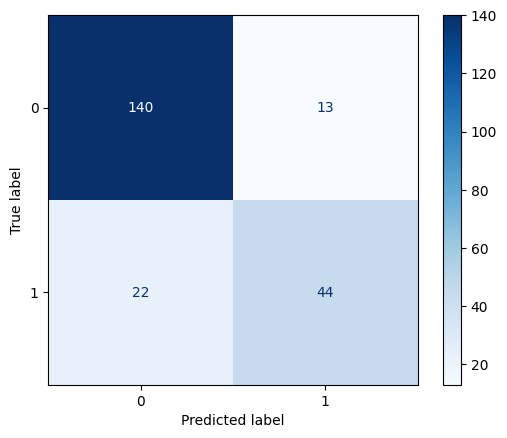

In [92]:
#MLP + TFIDF
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from imblearn.metrics import sensitivity_specificity_support
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
# get X and y
df_X = X_input_tfidf
df_y = df_resize['airline_sentiment']
#hold out, dibagi menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.3, random_state=42)
#label encoding for y
le = LabelEncoder()
le.fit(y_train)
y_train=le.transform(y_train)
y_test=le.fit_transform(y_test)
#mulai learning
model=MLPClassifier(max_iter=1000)
#model=MLPClassifier(max_iter=1000, random_state=42, activation='logistic')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Accuracy ',accuracy_score(y_test, y_pred))
print('Precision ',precision_score(y_test, y_pred))
print('Recall ',recall_score(y_test, y_pred))
print('Confusion matrix ', confusion_matrix(y_test, y_pred))
# plot_confusion_matrix(model, X_test, y_test, cmap=plt.cm.Blues)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
# plt.show()
disp.plot(cmap=plt.cm.Blues)
from sklearn.metrics import f1_score
print('F1 ',f1_score(y_test, y_pred, average='macro'))

Accuracy  0.7214611872146118
Precision  0.5294117647058824
Recall  0.6818181818181818
Confusion matrix  [[113  40]
 [ 21  45]]
F1  0.6917414680296283


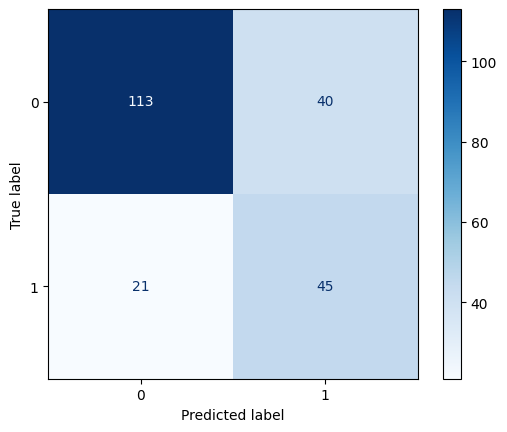

In [93]:
#DT + BOW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from imblearn.metrics import sensitivity_specificity_support
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
# get X and y
df_X = X_input_bow
df_y = df_resize['airline_sentiment']
#hold out, dibagi menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.3, random_state=42)
#label encoding for y
le = LabelEncoder()
le.fit(y_train)
y_train=le.transform(y_train)
y_test=le.fit_transform(y_test)
#mulai learning
model=DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Accuracy ',accuracy_score(y_test, y_pred))
print('Precision ',precision_score(y_test, y_pred))
print('Recall ',recall_score(y_test, y_pred))
print('Confusion matrix ', confusion_matrix(y_test, y_pred))
# plot_confusion_matrix(model, X_test, y_test, cmap=plt.cm.Blues)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
# plt.show()
disp.plot(cmap=plt.cm.Blues)
from sklearn.metrics import f1_score
print('F1 ',f1_score(y_test, y_pred, average='macro'))

Accuracy  0.7671232876712328
Precision  0.5925925925925926
Recall  0.7272727272727273
Confusion matrix  [[120  33]
 [ 18  48]]
F1  0.7389017462655165


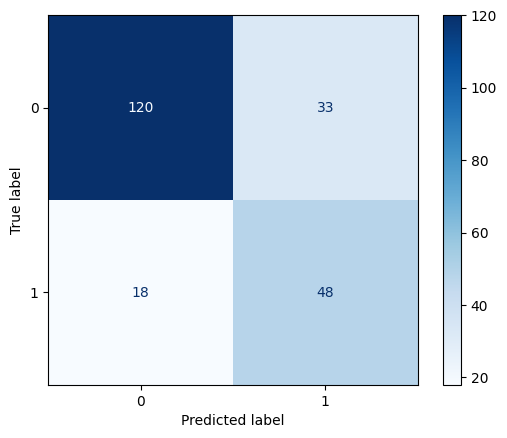

In [94]:
#DT + TFIDF
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from imblearn.metrics import sensitivity_specificity_support
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
# get X and y
df_X = X_input_tfidf
df_y = df_resize['airline_sentiment']
#hold out, dibagi menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.3, random_state=42)
#label encoding for y
le = LabelEncoder()
le.fit(y_train)
y_train=le.transform(y_train)
y_test=le.fit_transform(y_test)
#mulai learning
model=DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Accuracy ',accuracy_score(y_test, y_pred))
print('Precision ',precision_score(y_test, y_pred))
print('Recall ',recall_score(y_test, y_pred))
print('Confusion matrix ', confusion_matrix(y_test, y_pred))
# plot_confusion_matrix(model, X_test, y_test, cmap=plt.cm.Blues)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
# plt.show()
disp.plot(cmap=plt.cm.Blues)
from sklearn.metrics import f1_score
print('F1 ',f1_score(y_test, y_pred, average='macro'))

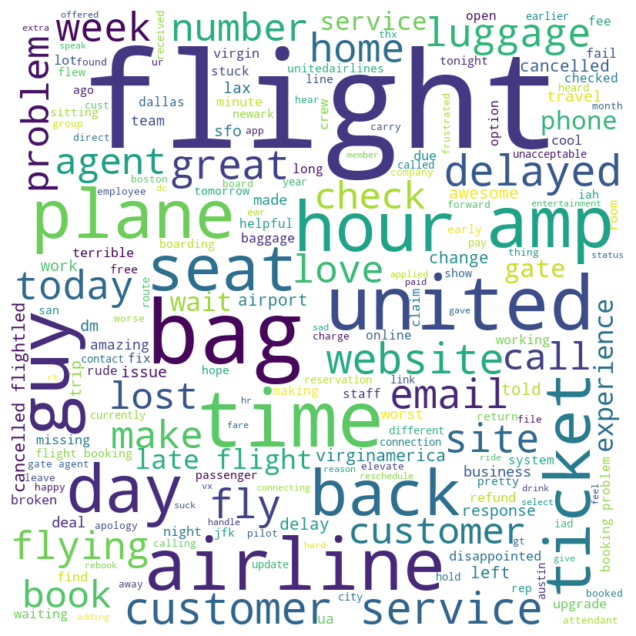

In [95]:
#Word CLoud
from wordcloud import WordCloud
text = ' '.join(new_doc)
wordcloud = WordCloud(width = 800, height = 800, background_color="white")
wordcloud = wordcloud.generate_from_text(text)
# Display the generated image:
plt.figure(figsize=(8, 8), dpi=100)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [96]:
text

'added commercial experience tacky aggressive blast obnoxious entertainment guest face amp recourse big pay flight seat playing flying time fly vx ear worm away virginamerica amazing arrived hour early lt pretty graphic minimal iconography great deal trip australia amp trip p virginmedia flying fabulous seductive sky stress away travel http  schedule excited cross country flight lax mco heard great thing virgin america flew nyc sfo week fully seat due large gentleman side flying amazingly awesome fly fare time carrier seat available select love graphic http love hipster innovation feel brand guy messed seating reserved seating friend guy gave seat away free internet status match program applied week called emailed response happened ur vegan food option ur site eat hr fail amazing cold air vent noair worstflightever roasted sfotobos bked cool birthday trip add elevate entered middle flight booking problem left expensive headphone flight iad lax today seat answering amp f number lax awai

In [97]:
# Format text dengan 10 kata per baris
words = text.split()
formatted_text = ""
for i in range(0, len(words), 10):
    line = " ".join(words[i:i+10])
    formatted_text += line + "\n"

print("Text dengan format 10 kata per baris:")
print(formatted_text)

Text dengan format 10 kata per baris:
added commercial experience tacky aggressive blast obnoxious entertainment guest face
amp recourse big pay flight seat playing flying time fly
vx ear worm away virginamerica amazing arrived hour early lt
pretty graphic minimal iconography great deal trip australia amp trip
p virginmedia flying fabulous seductive sky stress away travel http
schedule excited cross country flight lax mco heard great thing
virgin america flew nyc sfo week fully seat due large
gentleman side flying amazingly awesome fly fare time carrier seat
available select love graphic http love hipster innovation feel brand
guy messed seating reserved seating friend guy gave seat away
free internet status match program applied week called emailed response
happened ur vegan food option ur site eat hr fail
amazing cold air vent noair worstflightever roasted sfotobos bked cool
birthday trip add elevate entered middle flight booking problem left
expensive headphone flight iad lax today 

### **Tugas 2**
1. Silahkan mencari dataset lain. Dari dataset tersebut, ambil 1000 baris saja untuk mempercepat komputasi
2. Dengan menggunakan kombinasi antara BOW atau TF-IDF, pasangkan dengan model klasifikasi, seperti MLP, DT, RF, LR, AdaBoost, dll
3. Tampilkan hasilnya, dan pilih kombinasi terbaik (feature extraction method + classifier)

In [98]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/nadznaf/dataset_ppd/main/IMDB_small_size.csv', delimiter=',')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
9995,"Fun, entertaining movie about WWII German spy ...",positive
9996,Give me a break. How can anyone say that this ...,negative
9997,This movie is a bad movie. But after watching ...,negative
9998,This is a movie that was probably made to ente...,negative


In [99]:
# Setup - Import semua library yang diperlukan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Classifiers
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

# Text preprocessing
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("Setup completed successfully!")

Setup completed successfully!


Dataset Info:
Shape: (10000, 2)
Columns: ['review', 'sentiment']

Missing values:
review       0
sentiment    0
dtype: int64

Sentiment distribution:
sentiment
positive    5028
negative    4972
Name: count, dtype: int64


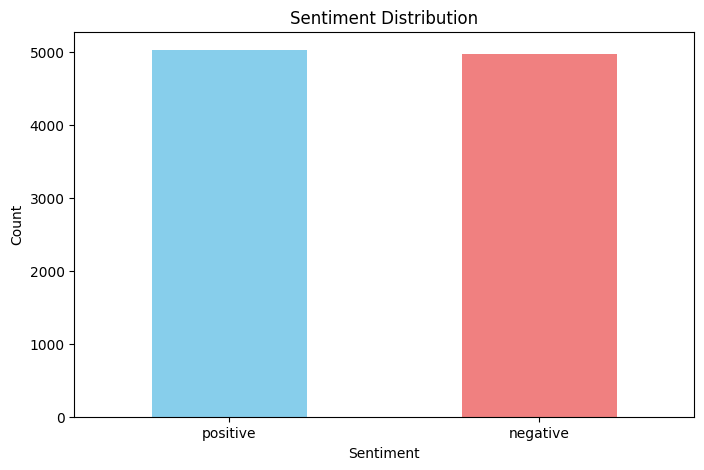


Sample positive review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...

Sample negative review:
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, J...


In [100]:
# Exploratory Data Analysis
print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# Check sentiment distribution
sentiment_counts = df['sentiment'].value_counts()
print(f"\nSentiment distribution:\n{sentiment_counts}")

# Plot sentiment distribution
plt.figure(figsize=(8, 5))
sentiment_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Sentiment Distribution')
plt.ylabel('Count')
plt.xlabel('Sentiment')
plt.xticks(rotation=0)
plt.show()

# Sample reviews
print("\nSample positive review:")
print(df[df['sentiment'] == 'positive']['review'].iloc[0][:200] + "...")
print("\nSample negative review:")
print(df[df['sentiment'] == 'negative']['review'].iloc[0][:200] + "...")

In [101]:
# Text Preprocessing Function
def preprocess_text(text):

    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower()
    text = ' '.join(text.split())
    return text

print("Preprocessing text...")
df['cleaned_review'] = df['review'].apply(preprocess_text)

print("Original review:")
print(df['review'].iloc[0][:200] + "...")
print("\nCleaned review:")
print(df['cleaned_review'].iloc[0][:200] + "...")

Preprocessing text...
Original review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...

Cleaned review:
one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its br...


In [102]:
# Prepare features and target
X = df['cleaned_review']
y = df['sentiment']

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training distribution:\n{y_train.value_counts()}")
print(f"Test distribution:\n{y_test.value_counts()}")

Training set: 7000 samples
Test set: 3000 samples
Training distribution:
sentiment
positive    3520
negative    3480
Name: count, dtype: int64
Test distribution:
sentiment
positive    1508
negative    1492
Name: count, dtype: int64


In [103]:
# Feature Extraction - BOW and TF-IDF
print("Creating feature vectors...")

# Bag of Words
bow_vectorizer = CountVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)  # Unigrams and bigrams
)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)  # Unigrams and bigrams
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"BOW features shape: {X_train_bow.shape}")
print(f"TF-IDF features shape: {X_train_tfidf.shape}")

# Label encoding
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Creating feature vectors...
BOW features shape: (7000, 5000)
TF-IDF features shape: (7000, 5000)
Label mapping: {'negative': 0, 'positive': 1}


In [104]:
# Define classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'MLP Neural Network': MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='linear', random_state=42)
}

print("Classifiers ready for training:")
for name in classifiers.keys():
    print(f"- {name}")

Classifiers ready for training:
- Logistic Regression
- Multinomial Naive Bayes
- Decision Tree
- Random Forest
- MLP Neural Network
- AdaBoost
- SVM


In [105]:
# Function to evaluate model
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, feature_type):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    return {
        'Model': model_name,
        'Feature_Type': feature_type,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1
    }

print("Evaluation function ready!")

Evaluation function ready!


In [ ]:
results = []

# Evaluate with BOW
print("\n=== BOW Features ===")
for name, clf in classifiers.items():
    print(f"Training {name}...")
    try:
        result = evaluate_model(
            clf, X_train_bow, X_test_bow,
            y_train_encoded, y_test_encoded,
            name, 'BOW'
        )
        results.append(result)
        print(f"  Accuracy: {result['Accuracy']:.4f}")
    except Exception as e:
        print(f"  Error: {str(e)}")

# Evaluate with TF-IDF
print("\n=== TF-IDF Features ===")
for name, clf in classifiers.items():
    print(f"Training {name}...")
    try:
        # Create new instance to avoid issues with already trained models
        if name == 'Logistic Regression':
            clf = LogisticRegression(max_iter=1000, random_state=42)
        elif name == 'Multinomial Naive Bayes':
            clf = MultinomialNB()
        elif name == 'Decision Tree':
            clf = DecisionTreeClassifier(random_state=42)
        elif name == 'Random Forest':
            clf = RandomForestClassifier(n_estimators=100, random_state=42)
        elif name == 'MLP Neural Network':
            clf = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
        elif name == 'AdaBoost':
            clf = AdaBoostClassifier(n_estimators=100, random_state=42)
        elif name == 'SVM':
            clf = SVC(kernel='linear', random_state=42)

        result = evaluate_model(
            clf, X_train_tfidf, X_test_tfidf,
            y_train_encoded, y_test_encoded,
            name, 'TF-IDF'
        )
        results.append(result)
        print(f"  Accuracy: {result['Accuracy']:.4f}")
    except Exception as e:
        print(f"  Error: {str(e)}")

print("\nTraining completed!")

Training and evaluating all combinations...
This may take a few minutes...

=== BOW Features ===
Training Logistic Regression...
  Accuracy: 0.8487
Training Multinomial Naive Bayes...
  Accuracy: 0.8450
Training Decision Tree...
  Accuracy: 0.7220
Training Random Forest...
  Accuracy: 0.8397
Training MLP Neural Network...
  Accuracy: 0.8440
Training AdaBoost...
  Accuracy: 0.7867
Training SVM...
  Accuracy: 0.8197

=== TF-IDF Features ===
Training Logistic Regression...
  Accuracy: 0.8737
Training Multinomial Naive Bayes...
  Accuracy: 0.8540
Training Decision Tree...
  Accuracy: 0.7077
Training Random Forest...
  Accuracy: 0.8377
Training MLP Neural Network...
  Accuracy: 0.8423
Training AdaBoost...
  Accuracy: 0.7717
Training SVM...
  Accuracy: 0.8703

Training completed!


In [108]:
# Create results DataFrame and display
results_df = pd.DataFrame(results)
results_df = results_df.round(4)

print("=== COMPLETE RESULTS ===")
print(results_df.to_string(index=False))

# Find best combination
best_result = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"\n=== BEST COMBINATION ===")
print(f"Model: {best_result['Model']}")
print(f"Feature Type: {best_result['Feature_Type']}")
print(f"Accuracy: {best_result['Accuracy']:.4f}")
print(f"Precision: {best_result['Precision']:.4f}")
print(f"Recall: {best_result['Recall']:.4f}")
print(f"F1 Score: {best_result['F1_Score']:.4f}")

=== COMPLETE RESULTS ===
                  Model Feature_Type  Accuracy  Precision  Recall  F1_Score
    Logistic Regression          BOW    0.8487     0.8488  0.8487    0.8486
Multinomial Naive Bayes          BOW    0.8450     0.8451  0.8450    0.8450
          Decision Tree          BOW    0.7220     0.7220  0.7220    0.7220
          Random Forest          BOW    0.8397     0.8398  0.8397    0.8397
     MLP Neural Network          BOW    0.8440     0.8440  0.8440    0.8440
               AdaBoost          BOW    0.7867     0.7884  0.7867    0.7863
                    SVM          BOW    0.8197     0.8197  0.8197    0.8197
    Logistic Regression       TF-IDF    0.8737     0.8741  0.8737    0.8736
Multinomial Naive Bayes       TF-IDF    0.8540     0.8541  0.8540    0.8540
          Decision Tree       TF-IDF    0.7077     0.7078  0.7077    0.7076
          Random Forest       TF-IDF    0.8377     0.8378  0.8377    0.8377
     MLP Neural Network       TF-IDF    0.8423     0.8424  0.84

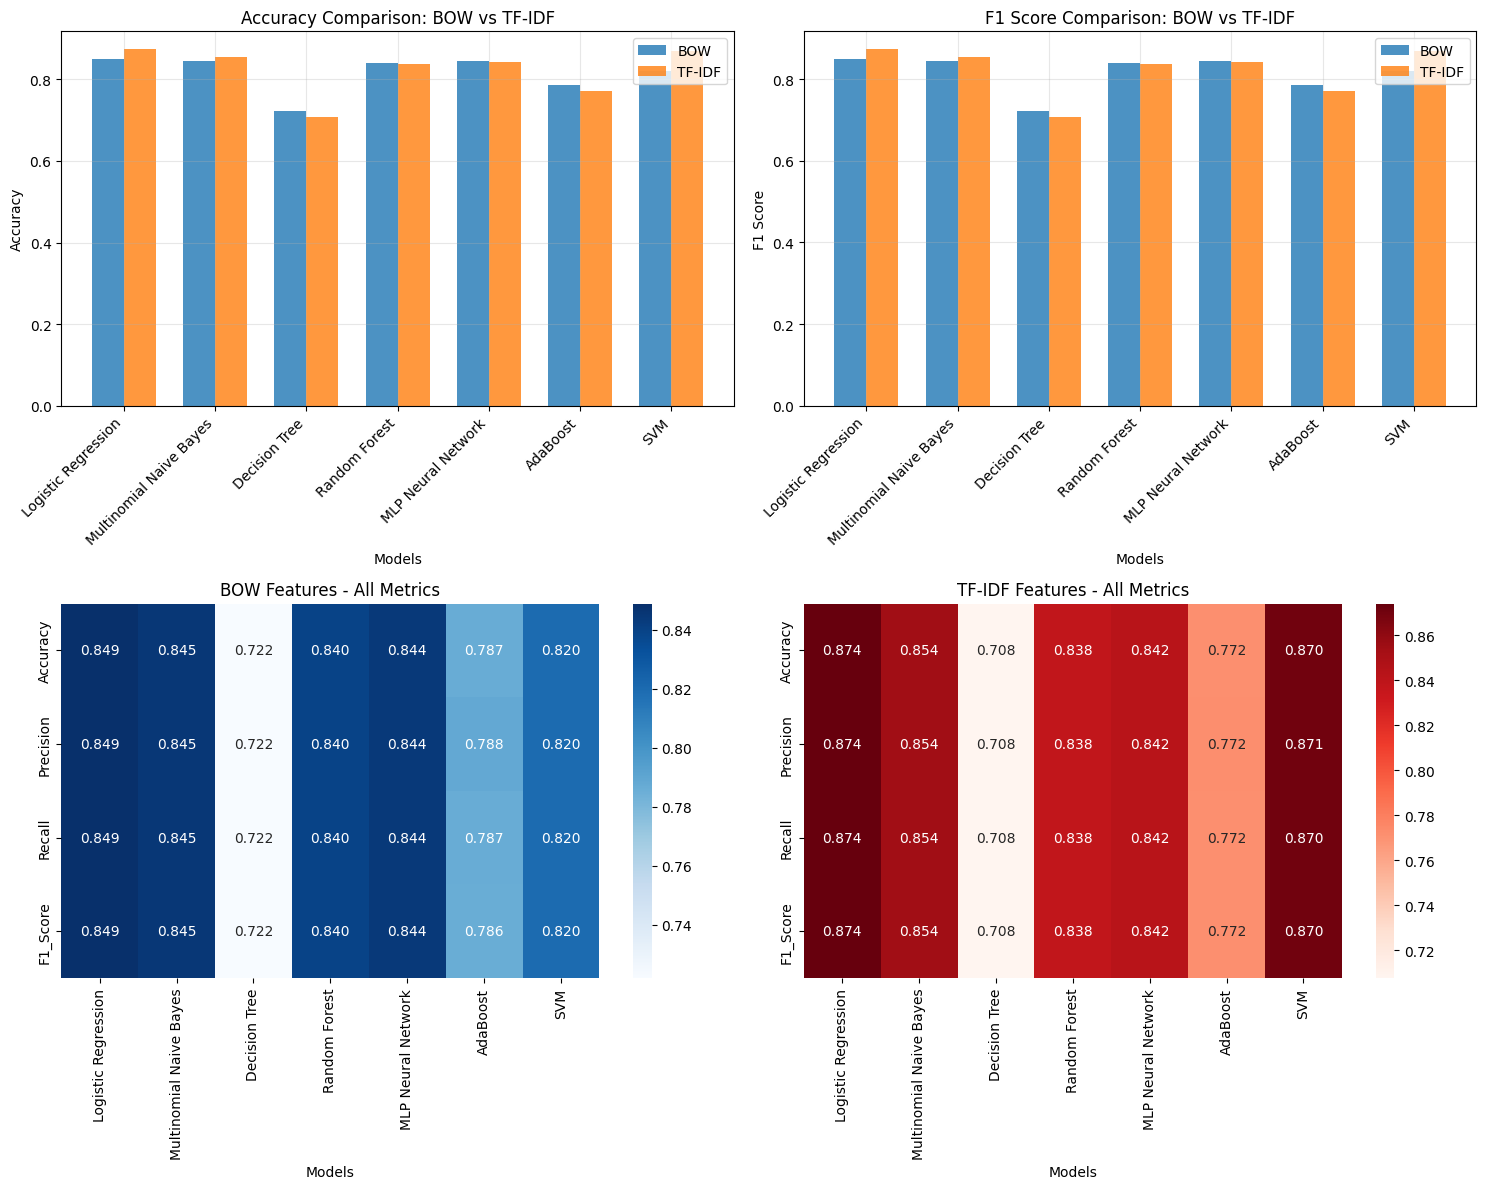

In [109]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Accuracy comparison
bow_results = results_df[results_df['Feature_Type'] == 'BOW']
tfidf_results = results_df[results_df['Feature_Type'] == 'TF-IDF']

x = range(len(bow_results))
width = 0.35

axes[0,0].bar([i - width/2 for i in x], bow_results['Accuracy'], width, label='BOW', alpha=0.8)
axes[0,0].bar([i + width/2 for i in x], tfidf_results['Accuracy'], width, label='TF-IDF', alpha=0.8)
axes[0,0].set_xlabel('Models')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].set_title('Accuracy Comparison: BOW vs TF-IDF')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(bow_results['Model'], rotation=45, ha='right')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. F1 Score comparison
axes[0,1].bar([i - width/2 for i in x], bow_results['F1_Score'], width, label='BOW', alpha=0.8)
axes[0,1].bar([i + width/2 for i in x], tfidf_results['F1_Score'], width, label='TF-IDF', alpha=0.8)
axes[0,1].set_xlabel('Models')
axes[0,1].set_ylabel('F1 Score')
axes[0,1].set_title('F1 Score Comparison: BOW vs TF-IDF')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(bow_results['Model'], rotation=45, ha='right')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Heatmap of all metrics for BOW
bow_pivot = bow_results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1_Score']]
sns.heatmap(bow_pivot.T, annot=True, cmap='Blues', fmt='.3f', ax=axes[1,0])
axes[1,0].set_title('BOW Features - All Metrics')
axes[1,0].set_xlabel('Models')

# 4. Heatmap of all metrics for TF-IDF
tfidf_pivot = tfidf_results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1_Score']]
sns.heatmap(tfidf_pivot.T, annot=True, cmap='Reds', fmt='.3f', ax=axes[1,1])
axes[1,1].set_title('TF-IDF Features - All Metrics')
axes[1,1].set_xlabel('Models')

plt.tight_layout()
plt.show()

=== DETAILED ANALYSIS OF BEST MODEL ===
Model: Logistic Regression + TF-IDF

Classification Report:
              precision    recall  f1-score   support

    negative     0.8873    0.8546    0.8706      1492
    positive     0.8612    0.8926    0.8766      1508

    accuracy                         0.8737      3000
   macro avg     0.8742    0.8736    0.8736      3000
weighted avg     0.8741    0.8737    0.8736      3000



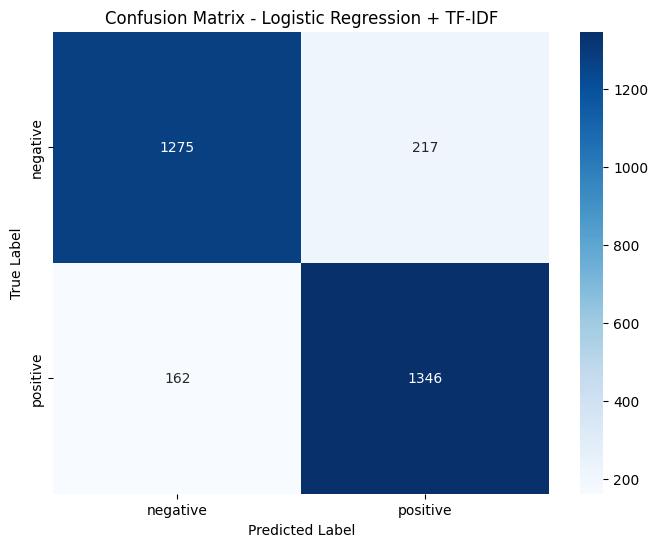


Top 10 words indicating POSITIVE sentiment:
  great: 5.0485
  excellent: 4.0934
  best: 3.4568
  love: 3.1227
  perfect: 2.9372
  wonderful: 2.9315
  loved: 2.8921
  amazing: 2.7815
  favorite: 2.5744
  brilliant: 2.4271

Top 10 words indicating NEGATIVE sentiment:
  bad: -5.3006
  worst: -4.6164
  awful: -4.0912
  waste: -3.9805
  boring: -3.9137
  stupid: -3.1855
  poor: -3.1071
  terrible: -2.9923
  horrible: -2.8278
  instead: -2.7887


In [110]:
# Detailed analysis of best model
print("=== DETAILED ANALYSIS OF BEST MODEL ===")
print("Model: Logistic Regression + TF-IDF")

# Retrain best model for detailed analysis
best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X_train_tfidf, y_train_encoded)
y_pred_best = best_model.predict(X_test_tfidf)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_best,
                          target_names=le.classes_,
                          digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - Logistic Regression + TF-IDF')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Feature importance (top words)
feature_names = tfidf_vectorizer.get_feature_names_out()
coef = best_model.coef_[0]

# Top positive words (indicating positive sentiment)
top_positive_indices = coef.argsort()[-20:][::-1]
top_positive_words = [(feature_names[i], coef[i]) for i in top_positive_indices]

# Top negative words (indicating negative sentiment)
top_negative_indices = coef.argsort()[:20]
top_negative_words = [(feature_names[i], coef[i]) for i in top_negative_indices]

print("\nTop 10 words indicating POSITIVE sentiment:")
for word, score in top_positive_words[:10]:
    print(f"  {word}: {score:.4f}")

print("\nTop 10 words indicating NEGATIVE sentiment:")
for word, score in top_negative_words[:10]:
    print(f"  {word}: {score:.4f}")